# MedSSL — Self-Supervised, Semi-Supervised, and Unsupervised Representation Learning Under Label Scarcity

**Standalone research notebook.** Pretrains a ResNet-50 encoder on chest X-rays with no labels at all, then reuses that single encoder as the shared starting point for three different learning paradigms — a label-efficiency comparison, a semi-supervised fine-tune, and an unsupervised clustering analysis.

## What this notebook does

1. Load the COVID-19 Radiography Database and carve out one fixed, held-out test split — used by every track below, never trained on.
2. Self-supervised pretrain a ResNet-50 from scratch with SimCLR on the unlabeled pool (Track A).
3. Evaluate that encoder's label efficiency against an ImageNet-pretrained baseline and a from-scratch-supervised baseline, at three label budgets (Track A eval).
4. Fine-tune the same pretrained encoder with a small labeled subset plus pseudo-labels from the unlabeled pool (Track B).
5. Cluster the frozen encoder's embeddings with no labels at all, and validate the clusters against true labels only after the fact (Track C).

The research question underneath all three tracks: **when labels are scarce, how much do self-supervised pretraining and semi-supervised fine-tuning actually buy you**, measured against the same encoder, the same held-out test set, and the same evaluation protocol throughout?

In [1]:
!pip install -q scikit-learn umap-learn seaborn rich
print("Packages installed.")

Packages installed.


## Step 1 — Configuration

In [2]:
from pathlib import Path

CFG = {
    # data
    "data_dir": "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset",
    "output_dir": "/kaggle/working/outputs",
    "seed": 42,
    "class_names": ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"],
    "image_size": 224,

    # splits
    "test_frac": 0.10,
    "val_frac": 0.10,               # reserved, not used in v1.0
    "max_test_samples": 800,
    "label_fractions": [0.01, 0.10, 1.00],
    "min_labels_per_class": 5,

    # backbone
    "backbone": "resnet50",
    "pretrained_imagenet_weights": "IMAGENET1K_V2",

    # Track A -- SimCLR pretraining
    "pretrain_pool_size": 6000,
    "pretrain_epochs": 15,
    "simclr_batch_size": 128,
    "projection_hidden_dim": 2048,
    "projection_output_dim": 128,
    "temperature": 0.1,
    "pretrain_lr": 3.0e-4,
    "pretrain_weight_decay": 1.0e-6,
    "warmup_frac": 0.1,
    "use_horizontal_flip": False,

    # augmentation
    "random_resized_crop_scale_min": 0.5,
    "rotation_degrees": 10,
    "brightness_jitter": 0.15,
    "contrast_jitter": 0.15,
    "gaussian_blur_prob": 0.5,
    "gaussian_noise_prob": 0.3,

    # downstream protocol
    "downstream_conditions": ["ssl_linear_probe", "imagenet_linear_probe", "from_scratch_supervised"],
    "linear_probe_epochs": 20,
    "linear_probe_lr": 1.0e-3,
    "from_scratch_epochs": 30,
    "from_scratch_lr": 1.0e-4,

    # Track B -- semi-supervised (confidence-thresholded pseudo-labeling)
    "semi_supervised_label_fraction": 0.01,
    "warm_start_epochs": 10,
    "pseudo_label_confidence_threshold": 0.95,
    "pseudo_label_rounds": 2,
    "max_pseudo_labels_per_class_per_round": 200,
    "unlabeled_pool_size_for_pseudo_labeling": 6000,
    "semi_supervised_epochs_per_round": 10,

    # Track C -- unsupervised (clustering + anomaly detection)
    "n_clusters": 4,
    "umap_n_neighbors": 15,
    "umap_min_dist": 0.1,
    "anomaly_percentile": 95,

    # visualization / evaluation
    "plot_dpi": 150,
    "gradcam_target_layer": "layer4",
}

output_dir = Path(CFG["output_dir"])
checkpoints_dir = output_dir / "checkpoints"
predictions_dir = output_dir / "predictions"
tables_dir = output_dir / "tables"
plots_dir = output_dir / "plots"
for d in [checkpoints_dir, predictions_dir, tables_dir, plots_dir]:
    d.mkdir(parents=True, exist_ok=True)

CFG

{'data_dir': '/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset',
 'output_dir': '/kaggle/working/outputs',
 'seed': 42,
 'class_names': ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia'],
 'image_size': 224,
 'test_frac': 0.1,
 'val_frac': 0.1,
 'max_test_samples': 800,
 'label_fractions': [0.01, 0.1, 1.0],
 'min_labels_per_class': 5,
 'backbone': 'resnet50',
 'pretrained_imagenet_weights': 'IMAGENET1K_V2',
 'pretrain_pool_size': 6000,
 'pretrain_epochs': 15,
 'simclr_batch_size': 128,
 'projection_hidden_dim': 2048,
 'projection_output_dim': 128,
 'temperature': 0.1,
 'pretrain_lr': 0.0003,
 'pretrain_weight_decay': 1e-06,
 'warmup_frac': 0.1,
 'use_horizontal_flip': False,
 'random_resized_crop_scale_min': 0.5,
 'rotation_degrees': 10,
 'brightness_jitter': 0.15,
 'contrast_jitter': 0.15,
 'gaussian_blur_prob': 0.5,
 'gaussian_noise_prob': 0.3,
 'downstream_conditions': ['ssl_linear_probe',
  'imagenet_linear_probe',
  'from_scratch_

## Step 2 — Verify the GPU

In [3]:
import torch

assert torch.cuda.is_available(), "No GPU found - enable GPU (T4 x1) in notebook settings."
gpu = torch.cuda.get_device_properties(0)
print(f"GPU: {gpu.name}")
print(f"VRAM: {gpu.total_memory / 1e9:.1f} GB")
print(f"Compute capability: {gpu.major}.{gpu.minor}")

GPU: Tesla T4
VRAM: 15.6 GB
Compute capability: 7.5


## Step 3 — Dataset: the COVID-19 Radiography Database

In [4]:
import random
from pathlib import Path

CANONICAL_CLASSES = CFG["class_names"]


def _normalize(name):
    return name.replace(" ", "").replace("_", "").replace("-", "").lower()


CANONICAL_MAP = {_normalize(c): c for c in CANONICAL_CLASSES}


def find_dataset_root(base, max_depth=2):
    """Breadth-first search for a directory containing most of the canonical class folders."""
    frontier = [base]
    for _ in range(max_depth + 1):
        next_frontier = []
        for d in frontier:
            if not d.is_dir():
                continue
            child_dirs = [c for c in d.iterdir() if c.is_dir()]
            child_names = {_normalize(c.name) for c in child_dirs}
            matches = sum(1 for k in CANONICAL_MAP if k in child_names)
            if matches >= 3:
                return d
            next_frontier.extend(child_dirs)
        frontier = next_frontier
    contents = [p.name for p in base.iterdir()] if base.is_dir() else "directory not found"
    raise FileNotFoundError(f"Could not locate the 4 class folders under {base}. Top-level contents: {contents}")


def discover_class_dirs(root):
    found = {}
    for child in root.iterdir():
        if not child.is_dir():
            continue
        key = _normalize(child.name)
        if key in CANONICAL_MAP:
            found[CANONICAL_MAP[key]] = child
    missing = set(CANONICAL_CLASSES) - set(found)
    if missing:
        raise FileNotFoundError(f"Missing class folders under {root}: {missing}. Found: {list(found)}")
    return found


def discover_images(class_dir):
    search_dir = class_dir / "images" if (class_dir / "images").is_dir() else class_dir
    images = sorted(search_dir.glob("*.png"))
    if not images:
        images = sorted(search_dir.glob("*.jpg")) + sorted(search_dir.glob("*.jpeg"))
    return images


def discover_mask(class_dir, image_path):
    mask_dir = class_dir / "masks"
    if mask_dir.is_dir():
        candidate = mask_dir / image_path.name
        if candidate.exists():
            return candidate
    return None


def load_image(sample):
    from PIL import Image
    return Image.open(sample["image_path"]).convert("RGB")


class CovidRadiographyDataset:
    def __init__(self, data_dir, seed=42):
        self.seed = seed
        root = find_dataset_root(Path(data_dir))
        self.class_dirs = discover_class_dirs(root)
        self.samples = []
        for class_name, class_dir in self.class_dirs.items():
            label_idx = CFG["class_names"].index(class_name)
            for img_path in discover_images(class_dir):
                self.samples.append({
                    "id": img_path.stem,
                    "image_path": img_path,
                    "mask_path": discover_mask(class_dir, img_path),
                    "label": class_name,
                    "label_idx": label_idx,
                })
        if not self.samples:
            raise FileNotFoundError(f"No images discovered under {root}")

    def __len__(self):
        return len(self.samples)

    def class_counts(self):
        counts = {c: 0 for c in CFG["class_names"]}
        for s in self.samples:
            counts[s["label"]] += 1
        return counts

    def stratified_split(self, test_frac=0.10, val_frac=0.10, max_test_samples=None, seed=42):
        by_class = {c: [] for c in CFG["class_names"]}
        for s in self.samples:
            by_class[s["label"]].append(s)

        test, val, dev = [], [], []
        for class_name, items in by_class.items():
            rng = random.Random(seed)
            shuffled = items.copy()
            rng.shuffle(shuffled)
            n_test = int(len(shuffled) * test_frac)
            n_val = int(len(shuffled) * val_frac)
            test.extend(shuffled[:n_test])
            val.extend(shuffled[n_test:n_test + n_val])
            dev.extend(shuffled[n_test + n_val:])

        if max_test_samples is not None and len(test) > max_test_samples:
            by_class_test = {c: [] for c in CFG["class_names"]}
            for s in test:
                by_class_test[s["label"]].append(s)
            total = len(test)
            capped = []
            rng = random.Random(seed)
            for class_name, items in by_class_test.items():
                share = max(1, round(max_test_samples * len(items) / total))
                rng.shuffle(items)
                capped.extend(items[:share])
            test = capped

        rng = random.Random(seed)
        rng.shuffle(test)
        rng.shuffle(val)
        rng.shuffle(dev)
        return dev, val, test

    def build_label_fraction_subset(self, pool, fraction, seed, min_per_class=5):
        by_class = {c: [] for c in CFG["class_names"]}
        for s in pool:
            by_class[s["label"]].append(s)

        subset = []
        rng = random.Random(seed)
        for class_name, items in by_class.items():
            shuffled = items.copy()
            rng.shuffle(shuffled)
            n = max(min_per_class, round(len(shuffled) * fraction))
            n = min(n, len(shuffled))
            subset.extend(shuffled[:n])
        rng.shuffle(subset)
        return subset

Total images discovered: 21165
  COVID              3616
  Lung_Opacity       6012
  Normal            10192
  Viral Pneumonia    1345


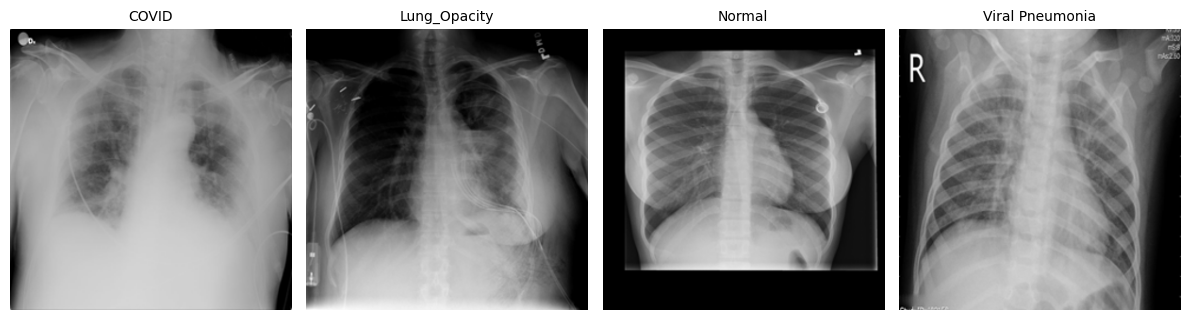

In [5]:
import matplotlib.pyplot as plt

dataset = CovidRadiographyDataset(CFG["data_dir"], seed=CFG["seed"])
counts = dataset.class_counts()
print(f"Total images discovered: {len(dataset)}")
for class_name, n in counts.items():
    print(f"  {class_name:16s} {n:6d}")

fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))
for ax, class_name in zip(axes, CFG["class_names"]):
    sample = next(s for s in dataset.samples if s["label"] == class_name)
    ax.imshow(load_image(sample), cmap="gray")
    ax.set_title(class_name, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 4 — Building the fixed splits

A single held-out test split is drawn now, stratified by class and seeded, and reused — literally the same Python objects — by every track in this notebook: the label-efficiency grid, the semi-supervised fine-tune, and the clustering analysis. Reusing the identical evaluation set means any measured gap is attributable to the method being compared, not to a differently-sampled test set.

This dataset provides no patient identifier anywhere in its metadata, so this split is at the *image* level, not the *patient* level.

In [6]:
dev_pool, val_split, test_split = dataset.stratified_split(
    test_frac=CFG["test_frac"],
    val_frac=CFG["val_frac"],
    max_test_samples=CFG["max_test_samples"],
    seed=CFG["seed"],
)
print(f"dev pool: {len(dev_pool)}  |  val (reserved, unused in v1.0): {len(val_split)}  |  test (fixed, shared by every track): {len(test_split)}")

test_by_class = {c: 0 for c in CFG["class_names"]}
for s in test_split:
    test_by_class[s["label"]] += 1
print("Test-split class counts:")
for c, n in test_by_class.items():
    print(f"  {c:16s} {n:6d}")

dev pool: 16935  |  val (reserved, unused in v1.0): 2115  |  test (fixed, shared by every track): 800
Test-split class counts:
  COVID               137
  Lung_Opacity        227
  Normal              385
  Viral Pneumonia      51


In [7]:
label_fraction_subsets = {}
for fraction in CFG["label_fractions"]:
    subset = dataset.build_label_fraction_subset(
        dev_pool, fraction, seed=CFG["seed"], min_per_class=CFG["min_labels_per_class"]
    )
    label_fraction_subsets[fraction] = subset

print(f"{'fraction':>10s} | " + " | ".join(f"{c:>14s}" for c in CFG["class_names"]) + " | total")
for fraction, subset in label_fraction_subsets.items():
    by_class = {c: 0 for c in CFG["class_names"]}
    for s in subset:
        by_class[s["label"]] += 1
    row = " | ".join(f"{by_class[c]:14d}" for c in CFG["class_names"])
    print(f"{fraction:>10.0%} | {row} | {len(subset):5d}")

  fraction |          COVID |   Lung_Opacity |         Normal | Viral Pneumonia | total
        1% |             29 |             48 |             82 |             11 |   170
       10% |            289 |            481 |            815 |            108 |  1693
      100% |           2894 |           4810 |           8154 |           1077 | 16935


## Step 5 — Augmentation pipeline for medical images

SimCLR's core trick (Step 6 covers this in full) is teaching a model that two different crops of the same image should map to similar representations. That only works if the augmentations used to make those two crops genuinely preserve the image's diagnostic content — an augmentation aggressive enough to change what the image actually shows would just teach the model the wrong lesson.

**More precisely, adapted for grayscale chest X-rays rather than copied from natural-image SimCLR:**

- **Random-resized crop** uses a narrower minimum scale (0.5, vs. natural-image SimCLR's 0.08) — an aggressive crop on a photo of a dog still shows "a dog"; an aggressive crop on a chest X-ray risks excising the one region carrying the actual diagnostic signal, manufacturing a "positive pair" that shares no meaningful content.
- **Small-angle rotation and mild blur/noise** model realistic variation in patient positioning and acquisition equipment.
- **Brightness/contrast jitter, not full color jitter** — chest X-rays are single-channel; SimCLR's signature aggressive `ColorJitter` (which perturbs hue and saturation) has no analogue on a grayscale image. A narrow brightness/contrast jitter is kept instead, justified as modeling realistic exposure and windowing differences across the dataset's several original source acquisitions.

**Horizontal flip is off by default.** Chest X-ray laterality is clinically meaningful — the cardiac silhouette sits on the anatomical left in the great majority of patients, and some real findings (a pneumothorax's side, a unilateral effusion) are laterality-dependent. Teaching a contrastive encoder that a flipped chest X-ray is "the same image" trains away a signal that some downstream tasks genuinely need, even though the four classes evaluated in this specific repo are largely bilateral or diffuse patterns rather than strongly lateralized ones. MoCo-CXR (Sowrirajan et al., 2021) treats horizontal flip with the same caution for the same reason. Given the asymmetric downside, the default here is conservative (`CFG["use_horizontal_flip"] = False`), exposed as a one-line toggle so it's trivially ablatable later.

In [8]:
import torch
import torchvision.transforms as T


class AddGaussianNoise:
    """Simulates detector/sensor noise -- applied after ToTensor, so it operates on pixel values in [0, 1]."""

    def __init__(self, std=0.02, p=0.3):
        self.std = std
        self.p = p

    def __call__(self, tensor):
        if random.random() < self.p:
            return torch.clamp(tensor + torch.randn_like(tensor) * self.std, 0.0, 1.0)
        return tensor


def build_simclr_augmentation(cfg):
    ops = [
        T.RandomResizedCrop(cfg["image_size"], scale=(cfg["random_resized_crop_scale_min"], 1.0)),
        T.RandomRotation(cfg["rotation_degrees"]),
    ]
    if cfg["use_horizontal_flip"]:
        ops.append(T.RandomHorizontalFlip(p=0.5))
    ops.append(T.RandomApply(
        [T.ColorJitter(brightness=cfg["brightness_jitter"], contrast=cfg["contrast_jitter"])], p=0.8,
    ))
    ops.append(T.RandomApply(
        [T.GaussianBlur(kernel_size=int(0.1 * cfg["image_size"]) | 1)], p=cfg["gaussian_blur_prob"],
    ))
    ops.append(T.ToTensor())
    ops.append(AddGaussianNoise(std=0.02, p=cfg["gaussian_noise_prob"]))
    return T.Compose(ops)


class SimCLRTwoViewTransform:
    """Returns two independently augmented views of the same image -- the positive pair NT-Xent trains on."""

    def __init__(self, cfg):
        self.transform = build_simclr_augmentation(cfg)

    def __call__(self, image):
        return self.transform(image), self.transform(image)


simclr_augmentation = SimCLRTwoViewTransform(CFG)

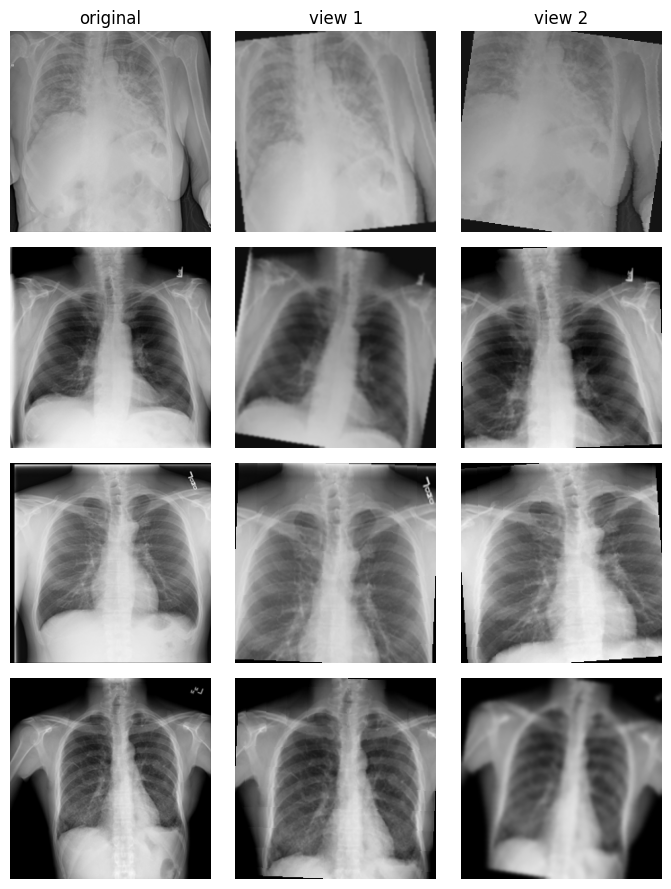

In [9]:
sample_ids = random.Random(CFG["seed"]).sample(range(len(dataset)), 4)
fig, axes = plt.subplots(4, 3, figsize=(7, 9))
for row, idx in enumerate(sample_ids):
    sample = dataset.samples[idx]
    image = load_image(sample)
    view1, view2 = simclr_augmentation(image)
    axes[row, 0].imshow(image, cmap="gray")
    axes[row, 1].imshow(view1.permute(1, 2, 0), cmap="gray")
    axes[row, 2].imshow(view2.permute(1, 2, 0), cmap="gray")
    if row == 0:
        axes[row, 0].set_title("original")
        axes[row, 1].set_title("view 1")
        axes[row, 2].set_title("view 2")
    for ax in axes[row]:
        ax.axis("off")
plt.tight_layout()
fig.savefig(plots_dir / "augmentation_pairs.png", dpi=CFG["plot_dpi"])
plt.show()

## Step 6 — How contrastive self-supervised learning works

**In plain terms:** take one unlabeled image and make two different augmented versions of it (Step 5). A contrastive model is trained to recognize that those two versions came from the same source image, out of a whole batch of other images' augmented versions. Do this over and over, across many images, and the model is forced to learn features that capture what actually makes an image *itself* — invariant to crop, rotation, and brightness — without ever being told what class it belongs to.

**More precisely — positive and negative pairs.** For a batch of `N` images, generate two augmented views of each, giving `2N` views total. For any one view (the "anchor"), its **positive** is the other view of the same source image; every other view in the batch is a **negative**. The training signal is: pull the anchor's representation close to its positive, and push it away from all `2(N-1)` negatives.

**The projection head.** The encoder's raw 2048-dim output isn't used directly in the loss — it first passes through a small projection head (`Linear → BatchNorm → ReLU → Linear`, down to 128 dimensions) that is *discarded* after pretraining. This is standard SimCLR practice: the projection head is free to distort the representation in whatever way makes the contrastive task easiest, and discarding it means that distortion doesn't carry over into the 2048-dim features actually used for every downstream task in this notebook.

**The NT-Xent / InfoNCE loss, worked through on a toy example.** Suppose a batch has just 2 images, giving 4 views: `A1, A2` (both from image A) and `B1, B2` (both from image B). For anchor `A1`, its positive is `A2`; its negatives are `B1` and `B2`. The loss computes cosine similarity between `A1` and every other view, divides by a temperature `τ`, and applies a softmax-cross-entropy that rewards `A1`'s similarity to `A2` being high relative to its similarity to `B1` and `B2`:

```
sim(u, v) = cosine_similarity(u, v)
L(A1) = -log[ exp(sim(A1, A2) / tau) / sum_{k != A1} exp(sim(A1, k) / tau) ]
```

This is computed for every one of the `2N` views as the anchor, and averaged. `τ` (temperature) controls how sharply the loss penalizes near-miss similarities — SimCLR's own grid search settled on `τ = 0.1`, used here unchanged.

**Batch size *is* the negative count — and that's a real, honestly-stated limitation of this notebook.** Because negatives come entirely from the batch, published SimCLR results use batch sizes from 256 up to 8,192 on TPU pods — far more negatives than a 16 GB T4 can hold at once for a ResNet-50 at 224x224. This notebook uses a batch size of 128 (256 views), one to two orders of magnitude below paper scale. **Read the resulting representation quality as evidence that the self-supervised-pretraining direction of improvement exists, not as a claim of state-of-the-art representation quality**.

**MoCo, briefly, as the alternative not implemented here.** Momentum Contrast (He et al., 2019) solves exactly this limitation by maintaining a large queue of negative representations from *previous* batches, decoupling negative count from batch size entirely — MoCo-CXR (Sowrirajan et al., 2021) applies exactly this to chest X-rays. 

**Other self-supervised paradigms, named for context, not implemented:** BYOL (Grill et al., 2020) and DINO/DINOv2 (Caron et al., 2021; Oquab et al., 2023) learn without any negative pairs at all, using a slowly-updated "teacher" network instead; MAE (He et al., 2021) is reconstruction-based rather than contrastive, masking patches of the input and training the model to reconstruct them.

In [10]:
import torch.nn as nn
import torchvision.models as tvm


def build_encoder(weights=None):
    """weights: None (random init), or a string like 'IMAGENET1K_V2' naming a torchvision weights enum member."""
    if isinstance(weights, str):
        weights = tvm.ResNet50_Weights[weights]
    model = tvm.resnet50(weights=weights)
    model.fc = nn.Identity()
    return model


class ProjectionHead(nn.Module):
    def __init__(self, in_dim=2048, hidden_dim=2048, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class SimCLRModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder = build_encoder(weights=None)
        self.projection_head = ProjectionHead(2048, cfg["projection_hidden_dim"], cfg["projection_output_dim"])

    def forward(self, x):
        features = self.encoder(x)
        projected = self.projection_head(features)
        return features, projected

## Step 8 — Track A: self-supervised pretraining

With the loss defined (Step 6) and the model built (Step 7), pretraining itself is an ordinary training loop: sample a batch, compute two augmented views per image, compute the NT-Xent loss, backpropagate, repeat. Every image passes through in each **epoch**; the whole pool is split into fixed-size **batches**; an **optimizer** (AdamW here) uses the gradient to update the model's weights each step.

**Why AdamW, not LARS.** Some published SimCLR results use the LARS optimizer specifically because it stabilizes training at very large batch sizes (thousands of images). At this notebook's batch size of 128, that instability doesn't arise, so introducing LARS's extra complexity would add machinery without a corresponding benefit — AdamW with a linear-warmup-then-cosine-decay schedule is used instead, a deliberate, scale-appropriate substitution rather than an oversight.

In [11]:
import torch.nn.functional as F


def nt_xent_loss(z1, z2, temperature):
    """NT-Xent / InfoNCE over a batch of N images -> 2N augmented views.
    For each anchor, the positive is the other view of the same source image;
    negatives are every other view in the batch (batch-as-negatives, no memory queue)."""
    batch_size = z1.shape[0]
    z = torch.cat([z1, z2], dim=0)
    z = F.normalize(z, dim=1)
    sim = torch.mm(z, z.t()) / temperature

    mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, float("-inf"))

    positive_idx = torch.arange(2 * batch_size, device=z.device)
    positive_idx = (positive_idx + batch_size) % (2 * batch_size)

    loss = F.cross_entropy(sim, positive_idx)
    return loss

In [12]:
import math
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR


class UnlabeledImageDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image = load_image(self.samples[idx])
        view1, view2 = self.transform(image)
        return view1, view2


pretrain_pool = random.Random(CFG["seed"]).sample(dev_pool, min(CFG["pretrain_pool_size"], len(dev_pool)))
pretrain_dataset = UnlabeledImageDataset(pretrain_pool, simclr_augmentation)
pretrain_loader = DataLoader(
    pretrain_dataset, batch_size=CFG["simclr_batch_size"], shuffle=True,
    num_workers=2, drop_last=True, pin_memory=True, persistent_workers=True,
)

device = torch.device("cuda")
simclr_model = SimCLRModel(CFG).to(device)
optimizer = AdamW(simclr_model.parameters(), lr=CFG["pretrain_lr"], weight_decay=CFG["pretrain_weight_decay"])

total_steps = CFG["pretrain_epochs"] * len(pretrain_loader)
warmup_steps = int(CFG["warmup_frac"] * total_steps)


def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))


scheduler = LambdaLR(optimizer, lr_lambda)
scaler = torch.amp.GradScaler("cuda")

pretrain_loss_history = []
simclr_model.train()
for epoch in range(CFG["pretrain_epochs"]):
    epoch_losses = []
    for view1, view2 in tqdm(pretrain_loader, desc=f"Track A epoch {epoch + 1}/{CFG['pretrain_epochs']}"):
        view1, view2 = view1.to(device), view2.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            _, z1 = simclr_model(view1)
            _, z2 = simclr_model(view2)
            loss = nt_xent_loss(z1, z2, CFG["temperature"])
        scaler.scale(loss).backward()
        prev_scale = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        if scaler.get_scale() >= prev_scale:
            scheduler.step()
        epoch_losses.append(loss.item())
    mean_loss = sum(epoch_losses) / len(epoch_losses)
    pretrain_loss_history.append(mean_loss)
    print(f"epoch {epoch + 1:2d}/{CFG['pretrain_epochs']}  mean NT-Xent loss: {mean_loss:.4f}")

/tmp/ipykernel_23/1218153182.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Track A epoch 1/15:   0%|          | 0/46 [00:00<?, ?it/s]

/tmp/ipykernel_23/1218153182.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_23/1218153182.py:61: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


epoch  1/15  mean NT-Xent loss: 5.2995


Track A epoch 2/15:   0%|          | 0/46 [00:00<?, ?it/s]

...

epoch 13/15  mean NT-Xent loss: 0.3953


Track A epoch 14/15:   0%|          | 0/46 [00:00<?, ?it/s]

epoch 14/15  mean NT-Xent loss: 0.3806


Track A epoch 15/15:   0%|          | 0/46 [00:00<?, ?it/s]

epoch 15/15  mean NT-Xent loss: 0.3778


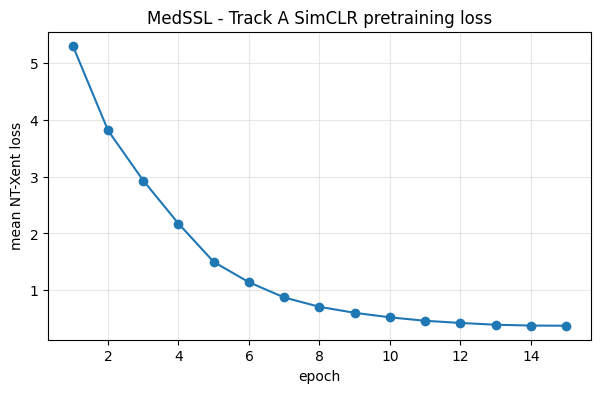

Saved pretrained encoder to /kaggle/working/outputs/checkpoints/simclr_encoder_resnet50.pt


In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(pretrain_loss_history) + 1), pretrain_loss_history, marker="o")
ax.set_xlabel("epoch")
ax.set_ylabel("mean NT-Xent loss")
ax.set_title("MedSSL - Track A SimCLR pretraining loss")
ax.grid(alpha=0.3)
fig.savefig(plots_dir / "simclr_pretrain_loss.png", dpi=CFG["plot_dpi"])
plt.show()

encoder_checkpoint_path = checkpoints_dir / "simclr_encoder_resnet50.pt"
torch.save(simclr_model.encoder.state_dict(), encoder_checkpoint_path)
print(f"Saved pretrained encoder to {encoder_checkpoint_path}")

## Step 9-10 — Downstream evaluation protocol

Three ways to use a pretrained (or not-pretrained) encoder for a classification task: a **linear probe** freezes the encoder entirely and trains only a small linear layer on top, directly measuring the quality of the frozen representation; **fine-tuning** unfreezes the encoder and trains it further alongside the head; **from-scratch** means the encoder itself starts from random weights and is trained end-to-end. This notebook's downstream grid compares three specific conditions built from these ingredients — SSL-pretrained + linear probe, ImageNet-pretrained + linear probe, and from-scratch fully trained — all sharing one `Linear(2048, 4)` classification head, so any AUROC gap between conditions is attributable to the encoder, not to head capacity.


**Why macro AUROC, not micro.** The metric is macro (unweighted) one-vs-rest AUROC, averaged equally across all four classes regardless of how many test images each class has. Weighting by class prevalence would let Normal (~48% of the full dataset) dominate the score — exactly the wrong incentive for a study whose entire point is how well a method handles the *rare* classes under label scarcity.

In [14]:
from sklearn.metrics import roc_auc_score
import numpy as np

NUM_CLASSES = len(CFG["class_names"])
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
DATASET_MEAN, DATASET_STD = [0.5, 0.5, 0.5], [0.5, 0.5, 0.5]  # fixed normalization for encoders that never saw ImageNet statistics


class LinearHead(nn.Module):
    def __init__(self, in_dim=2048, num_classes=NUM_CLASSES):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_classes)

    def forward(self, x):
        return self.fc(x)


class LabeledImageDataset(Dataset):
    """Deterministic eval/train-time preprocessing (resize + tensor + normalize), no SimCLR augmentation."""

    def __init__(self, samples, image_size, normalize_mean, normalize_std):
        self.samples = samples
        self.transform = T.Compose([
            T.Resize((image_size, image_size)),
            T.ToTensor(),
            T.Normalize(mean=normalize_mean, std=normalize_std),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = load_image(sample)
        return self.transform(image), sample["label_idx"]


def compute_class_weights(labels, num_classes):
    counts = torch.bincount(labels, minlength=num_classes).float()
    counts = torch.clamp(counts, min=1.0)
    return counts.sum() / (num_classes * counts)


def extract_embeddings(encoder, samples, normalize_mean, normalize_std, batch_size=64):
    ds = LabeledImageDataset(samples, CFG["image_size"], normalize_mean, normalize_std)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, persistent_workers=True)
    encoder.eval()
    all_features, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            features = encoder(images.to(device))
            all_features.append(features.cpu())
            all_labels.append(labels)
    return torch.cat(all_features), torch.cat(all_labels)


def train_head_on_cached_embeddings(features, labels, num_classes, cfg):
    head = LinearHead(features.shape[1], num_classes).to(device)
    class_weights = compute_class_weights(labels, num_classes).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = AdamW(head.parameters(), lr=cfg["linear_probe_lr"])
    features, labels = features.to(device), labels.to(device)
    head.train()
    for epoch in range(cfg["linear_probe_epochs"]):
        optimizer.zero_grad()
        loss = criterion(head(features), labels)
        loss.backward()
        optimizer.step()
    return head


def train_end_to_end(encoder_init_fn, samples, num_classes, cfg, epochs, lr):
    encoder = encoder_init_fn().to(device)
    head = LinearHead(2048, num_classes).to(device)
    labels_only = torch.tensor([s["label_idx"] for s in samples])
    class_weights = compute_class_weights(labels_only, num_classes).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = AdamW(list(encoder.parameters()) + list(head.parameters()), lr=lr)

    ds = LabeledImageDataset(samples, cfg["image_size"], DATASET_MEAN, DATASET_STD)
    loader = DataLoader(ds, batch_size=32, shuffle=True, num_workers=2, drop_last=len(ds) > 32, persistent_workers=True)

    encoder.train()
    head.train()
    for epoch in range(epochs):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(head(encoder(images)), labels)
            loss.backward()
            optimizer.step()
    return encoder, head


def predict_probs(encoder, head, samples, normalize_mean, normalize_std, batch_size=64):
    ds = LabeledImageDataset(samples, CFG["image_size"], normalize_mean, normalize_std)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, persistent_workers=True)
    encoder.eval()
    head.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            probs = F.softmax(head(encoder(images.to(device))), dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)


def evaluate_auroc(scores, labels, num_classes):
    """Macro one-vs-rest AUROC. scores: (N, C) softmax probabilities, labels: (N,) int array."""
    per_class_auroc = {}
    for c in range(num_classes):
        y_true = (labels == c).astype(int)
        if y_true.sum() == 0 or y_true.sum() == len(y_true):
            per_class_auroc[CFG["class_names"][c]] = float("nan")
            continue
        per_class_auroc[CFG["class_names"][c]] = roc_auc_score(y_true, scores[:, c])
    valid = [v for v in per_class_auroc.values() if not math.isnan(v)]
    macro_auroc = sum(valid) / len(valid)
    return macro_auroc, per_class_auroc

In [15]:
results_rows = []

for fraction in CFG["label_fractions"]:
    subset = label_fraction_subsets[fraction]

    encoder = build_encoder(weights=None).to(device)
    encoder.load_state_dict(torch.load(encoder_checkpoint_path, map_location=device))
    encoder.eval()
    for p in encoder.parameters():
        p.requires_grad_(False)

    train_features, train_labels = extract_embeddings(encoder, subset, DATASET_MEAN, DATASET_STD)
    head = train_head_on_cached_embeddings(train_features, train_labels, NUM_CLASSES, CFG)

    test_probs, test_labels = predict_probs(encoder, head, test_split, DATASET_MEAN, DATASET_STD)
    macro_auroc, per_class = evaluate_auroc(test_probs, test_labels, NUM_CLASSES)

    results_rows.append({
        "condition": "ssl_linear_probe", "label_fraction": fraction,
        "n_labeled": len(subset), "macro_auroc": macro_auroc, **per_class,
    })
    print(f"[ssl_linear_probe] {fraction:.0%} labels -> macro AUROC {macro_auroc:.3f}")

[ssl_linear_probe] 1% labels -> macro AUROC 0.753
[ssl_linear_probe] 10% labels -> macro AUROC 0.793
[ssl_linear_probe] 100% labels -> macro AUROC 0.765


### A normalization subtlety worth one sentence

The ImageNet-pretrained condition below normalizes images with ImageNet's channel mean/std, matching the statistics its pretrained weights actually expect. The SSL and from-scratch conditions use a simple fixed `[0.5, 0.5, 0.5]` normalization instead, since those encoders never saw ImageNet's specific pixel statistics during pretraining and have no reason to expect them. Easy to get silently wrong by reusing one normalization everywhere — worth flagging explicitly rather than leaving implicit in the code.

In [16]:
for fraction in CFG["label_fractions"]:
    subset = label_fraction_subsets[fraction]

    encoder = build_encoder(weights=CFG["pretrained_imagenet_weights"]).to(device)
    encoder.eval()
    for p in encoder.parameters():
        p.requires_grad_(False)

    train_features, train_labels = extract_embeddings(encoder, subset, IMAGENET_MEAN, IMAGENET_STD)
    head = train_head_on_cached_embeddings(train_features, train_labels, NUM_CLASSES, CFG)

    test_probs, test_labels = predict_probs(encoder, head, test_split, IMAGENET_MEAN, IMAGENET_STD)
    macro_auroc, per_class = evaluate_auroc(test_probs, test_labels, NUM_CLASSES)

    results_rows.append({
        "condition": "imagenet_linear_probe", "label_fraction": fraction,
        "n_labeled": len(subset), "macro_auroc": macro_auroc, **per_class,
    })
    print(f"[imagenet_linear_probe] {fraction:.0%} labels -> macro AUROC {macro_auroc:.3f}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s]


[imagenet_linear_probe] 1% labels -> macro AUROC 0.926
[imagenet_linear_probe] 10% labels -> macro AUROC 0.928
[imagenet_linear_probe] 100% labels -> macro AUROC 0.929


In [17]:
for fraction in CFG["label_fractions"]:
    subset = label_fraction_subsets[fraction]

    encoder, head = train_end_to_end(
        lambda: build_encoder(weights=None), subset, NUM_CLASSES, CFG,
        epochs=CFG["from_scratch_epochs"], lr=CFG["from_scratch_lr"],
    )

    test_probs, test_labels = predict_probs(encoder, head, test_split, DATASET_MEAN, DATASET_STD)
    macro_auroc, per_class = evaluate_auroc(test_probs, test_labels, NUM_CLASSES)

    results_rows.append({
        "condition": "from_scratch_supervised", "label_fraction": fraction,
        "n_labeled": len(subset), "macro_auroc": macro_auroc, **per_class,
    })
    print(f"[from_scratch_supervised] {fraction:.0%} labels -> macro AUROC {macro_auroc:.3f}")

[from_scratch_supervised] 1% labels -> macro AUROC 0.841
[from_scratch_supervised] 10% labels -> macro AUROC 0.959
[from_scratch_supervised] 100% labels -> macro AUROC 0.987


## Step 15 — The label-efficiency curve

In [18]:
import pandas as pd

results_df = pd.DataFrame(results_rows)
results_df.to_csv(tables_dir / "label_efficiency_results.csv", index=False)
results_df

,condition,label_fraction,n_labeled,macro_auroc,COVID,Lung_Opacity,Normal,Viral Pneumonia
0,ssl_linear_probe,0.01,170,0.752908,0.724742,0.674978,0.662360,0.949554
1,ssl_linear_probe,0.10,1693,0.793117,0.731347,0.762337,0.723392,0.955392
2,ssl_linear_probe,1.00,16935,0.764956,0.711343,0.729732,0.688199,0.930548
3,imagenet_linear_probe,0.01,170,0.926049,0.888331,0.910218,0.912896,0.992749
4,imagenet_linear_probe,0.10,1693,0.928118,0.903579,0.909403,0.912289,0.987199
5,imagenet_linear_probe,1.00,16935,0.929437,0.908831,0.915323,0.908252,0.985340
6,from_scratch_supervised,0.01,170,0.840894,0.815504,0.793397,0.826744,0.927930
7,from_scratch_supervised,0.10,1693,0.959070,0.968722,0.939279,0.937362,0.990916
8,from_scratch_supervised,1.00,16935,0.986794,0.995662,0.972730,0.978914,0.999869


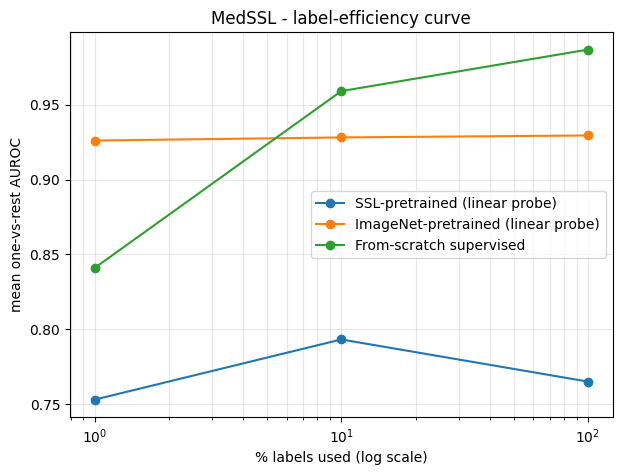

In [19]:
condition_labels = {
    "ssl_linear_probe": "SSL-pretrained (linear probe)",
    "imagenet_linear_probe": "ImageNet-pretrained (linear probe)",
    "from_scratch_supervised": "From-scratch supervised",
}

fig, ax = plt.subplots(figsize=(7, 5))
for condition, label in condition_labels.items():
    sub = results_df[results_df["condition"] == condition].sort_values("label_fraction")
    ax.plot(sub["label_fraction"] * 100, sub["macro_auroc"], marker="o", label=label)

ax.set_xscale("log")
ax.set_xlabel("% labels used (log scale)")
ax.set_ylabel("mean one-vs-rest AUROC")
ax.set_title("MedSSL - label-efficiency curve")
ax.legend()
ax.grid(alpha=0.3, which="both")
fig.savefig(plots_dir / "label_efficiency_curve.png", dpi=CFG["plot_dpi"])
plt.show()

## Step 16 — Semi-supervised pseudo-labeling

Start with a model trained on a small amount of labeled data. Run it over a much larger pool of unlabeled data, and for every prediction the model makes with high confidence, treat that prediction as if it were a real label — a "pseudo-label" — and add it to the training set. Retrain on the combined real-plus-pseudo-labeled data, and repeat. The idea is that a model's own most-confident predictions are usually its most-correct ones, so this extracts extra training signal from data that would otherwise go unused.

**The confirmation-bias failure mode, and the mitigation used here.** If the warm-start model is already biased toward the majority class (a real risk with only a dozen or so labeled examples of the rarest class), it will confidently — and wrongly — predict that class on much of the unlabeled pool, and pseudo-labeling would accept those wrong, confident predictions, making the bias worse with every round. The mitigation implemented below is a **per-class cap** on how many pseudo-labels can be accepted per class per round, which limits (but does not eliminate) this feedback loop — stated plainly as a real, only-partially-solved risk, not a solved problem.

In [20]:
semi_sup_fraction = CFG["semi_supervised_label_fraction"]
labeled_1pct = label_fraction_subsets[semi_sup_fraction]

semi_encoder = build_encoder(weights=None).to(device)
semi_encoder.load_state_dict(torch.load(encoder_checkpoint_path, map_location=device))
semi_head = LinearHead(2048, NUM_CLASSES).to(device)

labels_only = torch.tensor([s["label_idx"] for s in labeled_1pct])
class_weights = compute_class_weights(labels_only, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
params = list(semi_encoder.parameters()) + list(semi_head.parameters())
optimizer = AdamW(params, lr=CFG["from_scratch_lr"])

labeled_ds = LabeledImageDataset(labeled_1pct, CFG["image_size"], DATASET_MEAN, DATASET_STD)
labeled_loader = DataLoader(labeled_ds, batch_size=16, shuffle=True, num_workers=2, persistent_workers=True)

semi_encoder.train()
semi_head.train()
for epoch in range(CFG["warm_start_epochs"]):
    for images, labels in labeled_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(semi_head(semi_encoder(images)), labels)
        loss.backward()
        optimizer.step()
print(f"Warm start complete: {CFG['warm_start_epochs']} epochs on {len(labeled_1pct)} labeled images ({semi_sup_fraction:.0%})")

Warm start complete: 10 epochs on 170 labeled images (1%)


In [21]:
labeled_ids = {s["id"] for s in labeled_1pct}
unlabeled_pool_full = [s for s in dev_pool if s["id"] not in labeled_ids]
unlabeled_pool = random.Random(CFG["seed"]).sample(
    unlabeled_pool_full, min(CFG["unlabeled_pool_size_for_pseudo_labeling"], len(unlabeled_pool_full))
)

combined_labeled = list(labeled_1pct)

for round_idx in range(CFG["pseudo_label_rounds"]):
    probs, _ = predict_probs(semi_encoder, semi_head, unlabeled_pool, DATASET_MEAN, DATASET_STD)
    confidences = probs.max(axis=1)
    predicted = probs.argmax(axis=1)

    accepted_per_class = {c: 0 for c in range(NUM_CLASSES)}
    accepted = []
    order = confidences.argsort()[::-1]
    for idx in order:
        if confidences[idx] < CFG["pseudo_label_confidence_threshold"]:
            break
        c = int(predicted[idx])
        if accepted_per_class[c] >= CFG["max_pseudo_labels_per_class_per_round"]:
            continue
        sample = dict(unlabeled_pool[idx])
        sample["label_idx"] = c
        sample["label"] = CFG["class_names"][c]
        accepted.append(sample)
        accepted_per_class[c] += 1

    print(f"round {round_idx + 1}: accepted {len(accepted)} pseudo-labels "
          f"(threshold {CFG['pseudo_label_confidence_threshold']}, cap {CFG['max_pseudo_labels_per_class_per_round']}/class)")
    print(f"  per-class: {[CFG['class_names'][c] + '=' + str(n) for c, n in accepted_per_class.items()]}")

    combined_labeled = combined_labeled + accepted
    combined_labels_only = torch.tensor([s["label_idx"] for s in combined_labeled])
    class_weights = compute_class_weights(combined_labels_only, NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    combined_ds = LabeledImageDataset(combined_labeled, CFG["image_size"], DATASET_MEAN, DATASET_STD)
    combined_loader = DataLoader(combined_ds, batch_size=16, shuffle=True, num_workers=2, persistent_workers=True)

    semi_encoder.train()
    semi_head.train()
    for epoch in range(CFG["semi_supervised_epochs_per_round"]):
        for images, labels in combined_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(semi_head(semi_encoder(images)), labels)
            loss.backward()
            optimizer.step()

round 1: accepted 800 pseudo-labels (threshold 0.95, cap 200/class)
  per-class: ['COVID=200', 'Lung_Opacity=200', 'Normal=200', 'Viral Pneumonia=200']
round 2: accepted 800 pseudo-labels (threshold 0.95, cap 200/class)
  per-class: ['COVID=200', 'Lung_Opacity=200', 'Normal=200', 'Viral Pneumonia=200']


In [22]:
test_probs, test_labels = predict_probs(semi_encoder, semi_head, test_split, DATASET_MEAN, DATASET_STD)
semi_macro_auroc, semi_per_class = evaluate_auroc(test_probs, test_labels, NUM_CLASSES)
print(f"[semi_supervised @ {semi_sup_fraction:.0%}] macro AUROC: {semi_macro_auroc:.3f}")

semi_checkpoint_path = checkpoints_dir / "semi_supervised_encoder.pt"
torch.save(semi_encoder.state_dict(), semi_checkpoint_path)
print(f"Saved semi-supervised fine-tuned encoder to {semi_checkpoint_path}")

[semi_supervised @ 1%] macro AUROC: 0.880
Saved semi-supervised fine-tuned encoder to /kaggle/working/outputs/checkpoints/semi_supervised_encoder.pt


/tmp/ipykernel_23/868857240.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison_labels, rotation=20, ha="right")


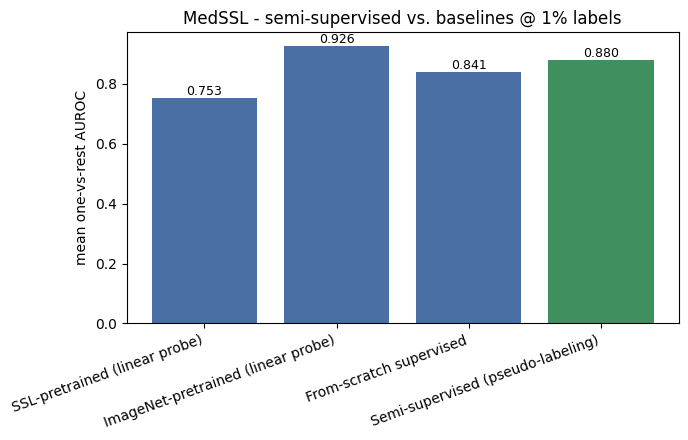

In [23]:
one_pct_rows = results_df[results_df["label_fraction"] == semi_sup_fraction].copy()
comparison_labels = [condition_labels[c] for c in one_pct_rows["condition"]]
comparison_values = list(one_pct_rows["macro_auroc"])
comparison_labels.append("Semi-supervised (pseudo-labeling)")
comparison_values.append(semi_macro_auroc)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(comparison_labels, comparison_values, color=["#4a6fa5", "#4a6fa5", "#4a6fa5", "#3f8f5f"])
ax.set_ylabel("mean one-vs-rest AUROC")
ax.set_title(f"MedSSL - semi-supervised vs. baselines @ {semi_sup_fraction:.0%} labels")
ax.set_xticklabels(comparison_labels, rotation=20, ha="right")
for bar, value in zip(bars, comparison_values):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
fig.savefig(plots_dir / "semi_supervised_comparison_1pct.png", dpi=CFG["plot_dpi"])
plt.show()

## Step 19 — Unsupervised clustering and anomaly detection work

Given a pile of embeddings with no labels at all, can an algorithm find meaningful groups on its own? **k-means** picks a number of cluster centers and repeatedly assigns each point to its nearest center, then moves each center to the average of the points assigned to it, until assignments stop changing. A **Gaussian Mixture Model (GMM)** does something similar but softer — instead of a hard assignment, it models the data as a mixture of overlapping Gaussian "blobs" and assigns each point a probability of belonging to each one. An **anomaly**, in this context, is simply a point that sits unusually far from every cluster center it's near — a rough proxy for "this image doesn't look like the others."

**More precisely — evaluating clusters without labels, and the post-hoc-only commitment.** **Silhouette score** measures how much closer, on average, each point is to its own cluster than to the next-nearest one — entirely computable from the embeddings and cluster assignments alone, no labels needed. **Cluster purity**, by contrast, *does* use labels: for each cluster, take the fraction of points belonging to that cluster's majority true class, and average across clusters. The critical distinction: purity is computed **after** k-means has already been fit, using labels only to *score* the resulting clusters, never to influence how they were formed. This matters here specifically because — unlike a genuinely unlabeled deployment scenario — every image in this dataset actually does have a label; using it during fitting would make "unsupervised" a fiction.

**Which pool, and why the test set.** Since every image here is technically labeled anyway, which images get clustered is a compute/scope decision, not a labels-availability constraint. The fixed, already-capped held-out test set is used — small enough to embed and cluster quickly, and reusing it keeps this track scored on the same data as Tracks A and B, consistent with the paired-comparison commitment stated back in the notebook's opening pipeline diagram.

In [24]:
clustering_encoder = build_encoder(weights=None).to(device)
clustering_encoder.load_state_dict(torch.load(encoder_checkpoint_path, map_location=device))
clustering_encoder.eval()

test_embeddings, test_true_labels = extract_embeddings(clustering_encoder, test_split, DATASET_MEAN, DATASET_STD)
test_embeddings_np = test_embeddings.numpy()
test_embeddings_normalized = test_embeddings_np / np.linalg.norm(test_embeddings_np, axis=1, keepdims=True)
test_true_labels_np = test_true_labels.numpy()
print(f"Embedded {len(test_embeddings_normalized)} test images into {test_embeddings_normalized.shape[1]}-dim, L2-normalized space.")

Embedded 800 test images into 2048-dim, L2-normalized space.


In [25]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score


kmeans = KMeans(n_clusters=CFG["n_clusters"], random_state=CFG["seed"], n_init=10)
kmeans_labels = kmeans.fit_predict(test_embeddings_normalized)

gmm = GaussianMixture(n_components=CFG["n_clusters"], random_state=CFG["seed"])
gmm_labels = gmm.fit_predict(test_embeddings_normalized)
gmm_log_likelihood = gmm.score_samples(test_embeddings_normalized)


def cluster_purity(cluster_labels, true_labels):
    """Majority-true-class fraction per cluster, weighted-averaged. Post-hoc only -- never used in fitting."""
    total_correct = 0
    for cluster_id in np.unique(cluster_labels):
        mask = cluster_labels == cluster_id
        majority_count = np.bincount(true_labels[mask]).max()
        total_correct += majority_count
    return total_correct / len(true_labels)


silhouette = silhouette_score(test_embeddings_normalized, kmeans_labels)
purity = cluster_purity(kmeans_labels, test_true_labels_np)

centroid_distances = np.linalg.norm(
    test_embeddings_normalized - kmeans.cluster_centers_[kmeans_labels], axis=1
)
anomaly_threshold = np.percentile(centroid_distances, CFG["anomaly_percentile"])
is_anomalous = centroid_distances >= anomaly_threshold

print(f"Silhouette score (k-means, post-hoc): {silhouette:.3f}")
print(f"Cluster purity (post-hoc, vs. true labels): {purity:.3f}")
print(f"Anomalies flagged: {is_anomalous.sum()} / {len(is_anomalous)} (top {100 - CFG['anomaly_percentile']}% by centroid distance)")

clustering_metrics_df = pd.DataFrame([{
    "silhouette_score": silhouette,
    "cluster_purity": purity,
    "gmm_mean_log_likelihood": float(gmm_log_likelihood.mean()),
    "anomaly_threshold_distance": anomaly_threshold,
    "n_anomalies": int(is_anomalous.sum()),
}])
clustering_metrics_df.to_csv(tables_dir / "clustering_metrics.csv", index=False)
clustering_metrics_df

Silhouette score (k-means, post-hoc): 0.225
Cluster purity (post-hoc, vs. true labels): 0.490
Anomalies flagged: 40 / 800 (top 5% by centroid distance)


,silhouette_score,cluster_purity,gmm_mean_log_likelihood,anomaly_threshold_distance,n_anomalies
0,0.225142,0.49,11856.721316,0.245264,40


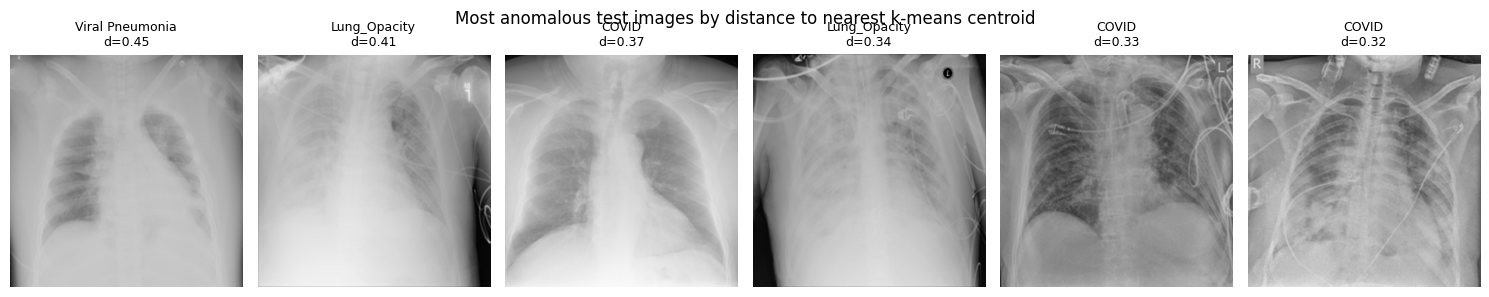

In [26]:
top_anomalous_idx = np.argsort(centroid_distances)[::-1][:6]
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for ax, idx in zip(axes, top_anomalous_idx):
    sample = test_split[idx]
    ax.imshow(load_image(sample), cmap="gray")
    ax.set_title(f"{sample['label']}\nd={centroid_distances[idx]:.2f}", fontsize=9)
    ax.axis("off")
plt.suptitle("Most anomalous test images by distance to nearest k-means centroid")
plt.tight_layout()
plt.show()

In [27]:
try:
    import umap
    reducer = umap.UMAP(
        n_neighbors=CFG["umap_n_neighbors"], min_dist=CFG["umap_min_dist"],
        random_state=CFG["seed"],
    )
    embedding_2d = reducer.fit_transform(test_embeddings_normalized)
    reducer_name = "UMAP"
except ImportError:
    from sklearn.manifold import TSNE
    reducer = TSNE(n_components=2, random_state=CFG["seed"])
    embedding_2d = reducer.fit_transform(test_embeddings_normalized)
    reducer_name = "t-SNE (umap-learn not installed -- fallback)"

print(f"2D projection computed via {reducer_name}.")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2D projection computed via UMAP.


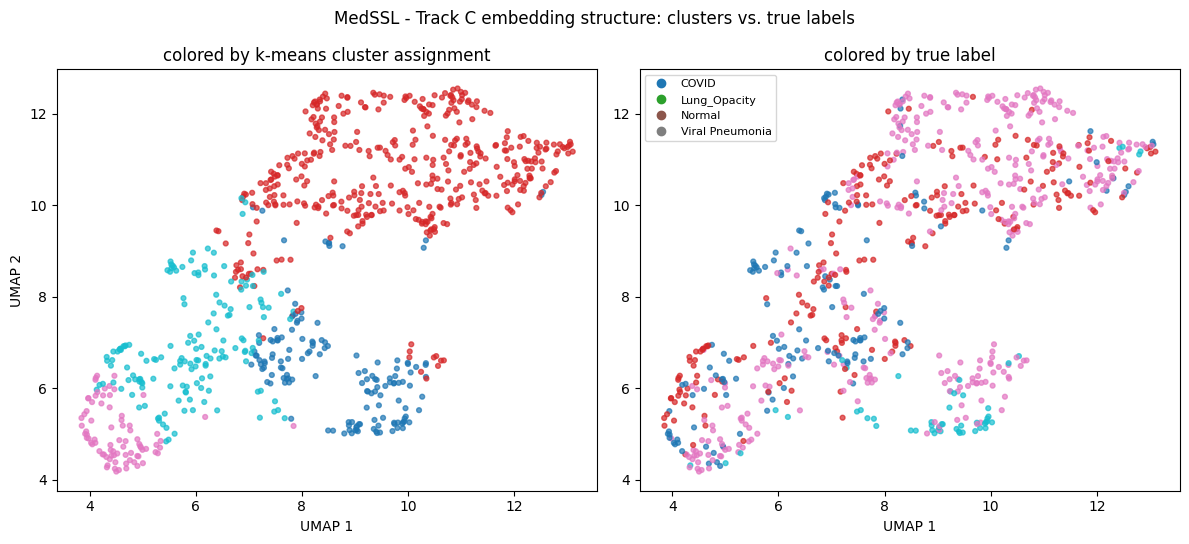

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=kmeans_labels, cmap="tab10", s=12, alpha=0.7)
axes[0].set_title("colored by k-means cluster assignment")
axes[0].set_xlabel(f"{reducer_name} 1")
axes[0].set_ylabel(f"{reducer_name} 2")

axes[1].scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=test_true_labels_np, cmap="tab10", s=12, alpha=0.7)
axes[1].set_title("colored by true label")
axes[1].set_xlabel(f"{reducer_name} 1")
handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=plt.cm.tab10(i / NUM_CLASSES), label=name)
           for i, name in enumerate(CFG["class_names"])]
axes[1].legend(handles=handles, fontsize=8, loc="best")

plt.suptitle("MedSSL - Track C embedding structure: clusters vs. true labels")
plt.tight_layout()
fig.savefig(plots_dir / "embedding_clusters_vs_labels.png", dpi=CFG["plot_dpi"])
plt.show()

## Step 22 — Grad-CAM: what is the fine-tuned model looking at?

Grad-CAM (Selvaraju et al., 2017) highlights which regions of an input image most influenced a specific prediction, by using the gradient of the predicted class score with respect to a late convolutional layer's activations as importance weights for those activations. Applied here to Track B's semi-supervised model specifically — it's the one model in this notebook genuinely fine-tuned end-to-end on real image pixels (the frozen linear-probe conditions never adapt their convolutional features at all, so a CAM on them would just highlight generic ImageNet-like or random-init edge patterns, not anything learned about this task).

**More precisely.** Only one architecture (ResNet-50) and one CAM variant are needed here, so a small hook-based implementation (~20 lines: a forward hook to capture `layer4`'s activations, a backward hook to capture their gradients, a weighted channel sum, upsampled back to image resolution) is written inline below rather than adding a third-party CAM library as a dependency — consistent with this notebook's convention of implementing every mechanism directly (NT-Xent, pseudo-labeling, cluster purity are all hand-rolled too) rather than importing it as a black box.

In [29]:
class GradCAM:
    """Hand-rolled, hook-based Grad-CAM (Selvaraju et al., 2017) -- one architecture (ResNet-50),
    one target layer, ~20 lines: no need for a third-party dependency."""

    def __init__(self, encoder, head, target_layer_name="layer4"):
        self.encoder = encoder
        self.head = head
        self.activations = None
        self.gradients = None
        target_layer = dict(encoder.named_modules())[target_layer_name]
        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, image_tensor, class_idx):
        self.encoder.zero_grad()
        self.head.zero_grad()
        features = self.encoder(image_tensor.unsqueeze(0).to(device))
        logits = self.head(features)
        logits[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=image_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

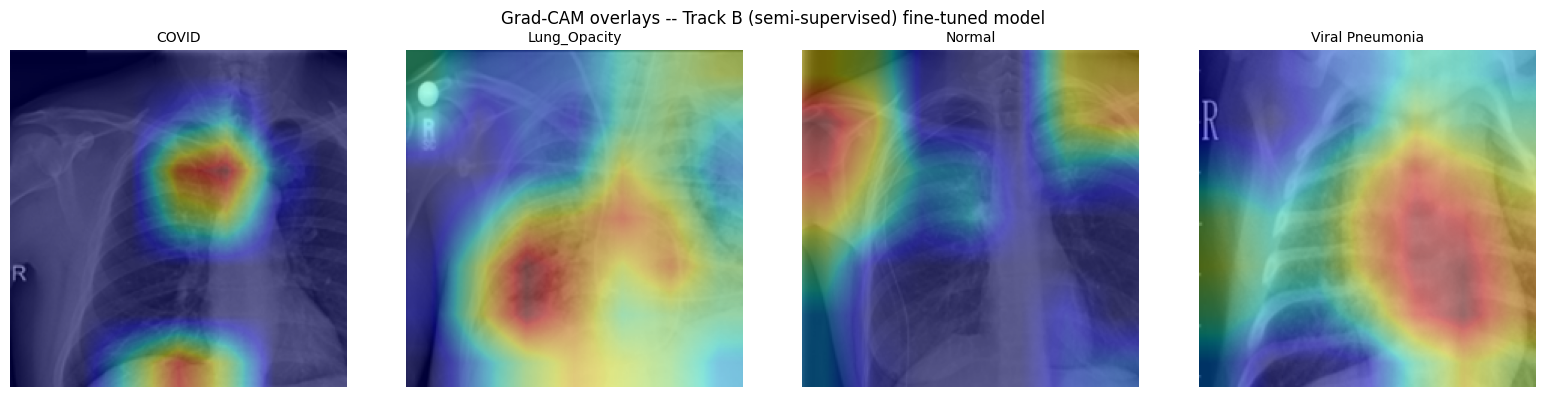

In [30]:
gradcam = GradCAM(semi_encoder, semi_head, target_layer_name=CFG["gradcam_target_layer"])

sample_per_class = []
for class_name in CFG["class_names"]:
    candidates = [s for s in test_split if s["label"] == class_name]
    if candidates:
        sample_per_class.append(random.Random(CFG["seed"]).choice(candidates))

eval_transform = T.Compose([
    T.Resize((CFG["image_size"], CFG["image_size"])),
    T.ToTensor(),
    T.Normalize(mean=DATASET_MEAN, std=DATASET_STD),
])

fig, axes = plt.subplots(1, len(sample_per_class), figsize=(4 * len(sample_per_class), 4))
for ax, sample in zip(axes, sample_per_class):
    image = load_image(sample)
    image_tensor = eval_transform(image)
    cam = gradcam(image_tensor, class_idx=sample["label_idx"])

    ax.imshow(image, cmap="gray")
    ax.imshow(cam, cmap="jet", alpha=0.4)
    ax.set_title(sample["label"], fontsize=10)
    ax.axis("off")

plt.suptitle("Grad-CAM overlays -- Track B (semi-supervised) fine-tuned model")
plt.tight_layout()
fig.savefig(plots_dir / "gradcam_overlays.png", dpi=CFG["plot_dpi"])
plt.show()


### What this notebook demonstrates

- **Self-supervised learning** (Track A) — SimCLR contrastive pretraining of a ResNet-50 from scratch, no labels used, with an honestly-stated small-batch limitation relative to paper-scale SimCLR.
- **Semi-supervised learning** (Track B) — confidence-thresholded pseudo-labeling that extends a small labeled subset with the model's own confident predictions on unlabeled data, with an explicit confirmation-bias mitigation.
- **Unsupervised learning** (Track C) — k-means/GMM clustering and anomaly detection with zero labels used in fitting, validated strictly post hoc.
- A label-efficiency comparison isolating what self-supervised pretraining specifically buys over an ImageNet-pretrained baseline and a from-scratch-supervised baseline, at three label budgets, on one shared held-out test set.

### References

- Chen, T., Kornblith, S., Norouzi, M., Hinton, G. (2020). *A Simple Framework for Contrastive Learning of Visual Representations*. arXiv:2002.05709
- Sohn, K., et al. (2020). *FixMatch: Simplifying Semi-Supervised Learning with Consistency and Confidence*. arXiv:2001.07685
- Lee, D.-H. (2013). *Pseudo-Label: The Simple and Efficient Semi-Supervised Learning Method for Deep Neural Networks*. ICML 2013 Workshop on Challenges in Representation Learning

Full reference list, including the medical-CXR-specific prior art (MoCo-CXR, RAD-DINO, MRM), in the README.


## Glossary

One-line definitions of every technical term used in this notebook, in the order concepts roughly build on each other. See the step referenced for the full explanation.

**Modeling basics**
- **Encoder** – the part of a model that turns an image into a fixed-length feature vector. (Step 7)
- **Weights / parameters** – the numbers a model learns during training. (Step 6)
- **Gradient / backpropagation** – the signal, computed from the loss, that says how to adjust each weight. (Step 8)
- **Optimizer** – the algorithm (here, AdamW) that uses the gradient to actually update the weights. (Step 8)
- **Epoch / batch** – one full pass over the training data / one chunk of it processed at a time. (Step 8)
- **Inference** – running a trained model forward to get a prediction, with no weight updates. (Step 12)

**Self-supervised learning and contrastive learning**
- **Self-supervised learning** – training on unlabeled data using a task the data defines itself. (Step 6)
- **Contrastive learning** – a self-supervised approach that pulls together representations of similar things and pushes apart representations of dissimilar things. (Step 6)
- **Positive pair / negative pair** – two augmented views of the same image / views of different images, within a training batch. (Step 6)
- **Augmentation** – a randomized transformation (crop, rotation, jitter) applied to an image to create a different "view" of it. (Step 5)
- **Projection head** – a small network appended to the encoder only during contrastive pretraining, discarded afterward. (Step 6)
- **NT-Xent / InfoNCE loss** – the specific contrastive loss function SimCLR uses. (Step 6)
- **Temperature (tau)** – a scaling factor in the contrastive loss controlling how sharply it penalizes near-miss similarities. (Step 6)
- **SimCLR** – the specific contrastive self-supervised method implemented in Track A. (Step 6)
- **MoCo** – an alternative contrastive method using a negative-sample queue instead of relying on batch size; not implemented here. (Step 6)

**Downstream evaluation protocol**
- **Linear probe** – freezing a pretrained encoder and training only a small linear classifier on top of it. (Step 10)
- **Fine-tuning** – unfreezing a pretrained encoder and training it further, alongside a classification head. (Step 10)
- **From-scratch training** – training an encoder from randomly initialized weights, with no pretraining at all. (Step 10)
- **Label efficiency** – how much task performance a method gets per labeled example. (Step 15)
- **AUROC (Area Under the ROC Curve)** – a metric for how well a classifier ranks positive examples above negative ones; here, macro-averaged one-vs-rest across four classes. (Step 10)
- **Class weighting** – upweighting the loss for under-represented classes so they aren't ignored during training. (Step 11)

**Semi-supervised learning**
- **Semi-supervised learning** – using a small labeled dataset together with a larger unlabeled one. (Step 16)
- **Pseudo-labeling** – treating a model's own confident predictions on unlabeled data as if they were real labels. (Step 16)
- **Confidence threshold** – the minimum prediction confidence required to accept a pseudo-label. (Step 16)
- **Confirmation bias (in pseudo-labeling)** – the risk that an already-biased model's wrong-but-confident predictions get accepted and reinforced. (Step 16)
- **FixMatch** – a more sophisticated semi-supervised method combining pseudo-labeling with a weak/strong-augmentation consistency loss; not implemented here. (Step 16)

**Unsupervised learning and clustering**
- **Unsupervised learning** – finding structure in data with no labels used anywhere. (Step 19)
- **k-means** – a clustering algorithm that assigns points to the nearest of k centers, iteratively updated. (Step 19)
- **Gaussian Mixture Model (GMM)** – a softer, probabilistic clustering method modeling data as overlapping Gaussian components. (Step 19)
- **Silhouette score** – a label-free measure of how well-separated clusters are. (Step 19)
- **Cluster purity** – a label-based, post-hoc measure of how well clusters align with true classes. (Step 19)
- **Anomaly detection** – flagging points that sit unusually far from every cluster center. (Step 19)
- **UMAP / t-SNE** – algorithms for projecting high-dimensional embeddings down to 2D for visualization. (Step 21)
- **Grad-CAM** – a technique that highlights which image regions most influenced a model's prediction. (Step 22)

**Hardware**
- **VRAM** – the memory available on a GPU, the hard limit on batch size and model size. (Step 2)
- **Compute capability** – a version number describing which operations a specific GPU architecture supports natively. (Step 2)
- **Mixed precision (AMP)** – training with a mix of 16- and 32-bit floating point numbers to reduce memory use and increase speed. (Step 8)